In [1]:
!pip install pandas==1.5.3
!pip install matplotlib
!pip install requests
!pip install scikit-learn
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 12.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.3/502.3 kB 21.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 6.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 2.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import requests
from datetime import datetime
import seaborn as sns
sns.set_theme()

2023-04-10 01:25:13.448330: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:

def getDpb(tc, pr, pbx = 0, pbn = 0):
    dpb = 0    
    if(tc):
        if(pr):
            dpb = pbx - pbn
        else:
            dpb = 0.06
    return dpb

def getPo(pr, pbx = 0, pbn= 0):
    po = 0
    if (pr):
        po = np.mean(np.array([pbx, pbn]))
    return po


def getPbxi(pr, pbx):
    pbxi = 0.03
    if(pr):
        pbxi = pbx
    return pbxi

def getTempLiqTb(tbx, tbn, taa, alpha, i):
    return taa - 0.003*i*a

In [4]:
response = requests.get('http://losses_data_service:5000/api/v1/losses-data/get-measurements-per-minute')
response2 = requests.get('http://losses_data_service:5000/api/v1/losses-data/get-meteorologies')
response3 = requests.get('http://losses_data_service:5000/api/v1/losses-data/get-oil-gas/2')

In [5]:
data = response.json()
meteorologies = response2.json()
oil_gas = response3.json()

In [6]:

dataset = dict()
dates = []
value_type = []
units = []
tanks = []
diameter = []
spaceTank = []
isIsolated = []
hlx = []
hln = []
v1= []
v2 = []
pmLiquid = []
pmVapor = []
tankHeight = []
substance = []
alpha = []
a = []
b = []
kc = []
pr = []
tc= []
hro = []
ge = []
hs = []

for row in data['measurements']:
    dates.append(row['date'])
    for measurementData in row['measurementData']:
        
        if(measurementData['valueType']['name'] == 'NIVEL DE PRODUCTO'):
            v1.append( np.float64(measurementData['value']))
            units.append(measurementData['unit']['symbol'])
        
        elif(measurementData['valueType']['name'] == 'TEMPERATURA RADAR'):
            v2.append( np.float64(measurementData['value']))
            units.append( measurementData['unit']['symbol'])

    #substances
    pmLiquid.append( np.float64(row['substance']['pmLiquid'] ))
    pmVapor.append( np.float64(row['substance']['pmVapor'] ))
    a.append( np.float64(row['substance']['a'] ))
    b.append( np.float64(row['substance']['b'] ))
    kc.append( np.float64(row['substance']['kc'] ))
    substance.append( row['substance']['name'] )
    
    ##Tanque
    isIsolated.append(row['tank']['isIsolated'])
    diameter.append( np.float64(row['tank']['diameter']) )
    alpha.append( np.float64( row['tank']['alfa']) )
    hlx.append( np.float64(row['tank']['hlx'] ))
    hln.append( np.float64(row['tank']['hln'] ))
    spaceTank.append( np.float64(row['tank']['spaceTank']) )
    tanks.append( row['tank']['name'])
    pr.append( 1 if row['tank']['pr'] else 0)
    tc.append( 1 if row['tank']['tc'] else 0)
    hro.append( row['tank']['hro'])
    ge.append( 1 if row['tank']['ge'] else 0)
    hs.append( np.float64(row["tank"]["hs"] ) )

In [7]:
dataset = pd.DataFrame(
    {'date':dates,
     'pr':pr,
     'tank':tanks,
     'isIsolated':isIsolated,
     'diameter':diameter,
     'alpha':alpha,
     'hlx':hlx,
     'hln':hln,
     'spaceTank':spaceTank,
     'NIVEL DE PRODUCTO':v1, 
     'TEMPERATURA RADAR':v2,
     'substance':substance,
     'pmLiquid':pmLiquid,
     'pmVapor':pmVapor,
     'a':a,
     'b':b,
     'kc':kc,
     'tc':tc,
     'hro':np.float64(hro),
     'ge':ge,
     'hs':hs
    })

In [8]:
dataset.columns

Index(['date', 'pr', 'tank', 'isIsolated', 'diameter', 'alpha', 'hlx', 'hln',
       'spaceTank', 'NIVEL DE PRODUCTO', 'TEMPERATURA RADAR', 'substance',
       'pmLiquid', 'pmVapor', 'a', 'b', 'kc', 'tc', 'hro', 'ge', 'hs'],
      dtype='object')

In [9]:
dataset.info

<bound method DataFrame.info of                       date  pr   tank  isIsolated  diameter  alpha        hlx  \
0      26-02-2023 00:00:00   0  K1505           0      12.0   0.25  20.528215   
1      26-02-2023 00:01:00   0  K1505           0      12.0   0.25  20.528215   
2      26-02-2023 00:02:00   0  K1505           0      12.0   0.25  20.528215   
3      26-02-2023 00:03:00   0  K1505           0      12.0   0.25  20.528215   
4      26-02-2023 00:04:00   0  K1505           0      12.0   0.25  20.528215   
...                    ...  ..    ...         ...       ...    ...        ...   
44635  28-03-2023 23:55:00   0  K1505           0      12.0   0.25  20.528215   
44636  28-03-2023 23:56:00   0  K1505           0      12.0   0.25  20.528215   
44637  28-03-2023 23:57:00   0  K1505           0      12.0   0.25  20.528215   
44638  28-03-2023 23:58:00   0  K1505           0      12.0   0.25  20.528215   
44639  28-03-2023 23:59:00   0  K1505           0      12.0   0.25  20.528215

In [10]:
#plt.plot(dataset['date'], dataset['NIVEL DE PRODUCTO'])
#plt.show()

In [11]:
#plt.plot(dataset['date'], dataset['TEMPERATURA RADAR'])
#plt.show()

In [12]:
dataset['date'] = pd.to_datetime(dataset['date'], yearfirst=False, format='%d-%m-%Y %H:%M:%S')
dataset.describe()

,pr,isIsolated,diameter,alpha,hlx,hln,spaceTank,NIVEL DE PRODUCTO,TEMPERATURA RADAR,pmLiquid,pmVapor,a,b,kc,tc,hro,ge,hs
count,44640.0,44640.0,44640.0,44640.00,4.464000e+04,4.464000e+04,44640.000,44640.000000,44640.000000,4.464000e+04,4.464000e+04,4.464000e+04,4.464000e+04,44640.0,44640.0,44640.000,44640.0,44640.0
mean,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,3154.251459,87.128138,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0
std,0.0,0.0,0.0,0.00,3.552753e-15,8.881884e-16,0.000,1953.741614,4.218161,2.842203e-14,2.842203e-14,5.329130e-15,1.819010e-12,0.0,0.0,0.000,0.0,0.0
min,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,936.000000,78.001600,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0
25%,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,1145.470000,83.549450,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0
50%,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,2823.470000,86.492900,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0
75%,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,5098.952500,90.453975,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0
max,0.0,0.0,12.0,0.25,2.052821e+01,3.280840e+00,0.125,6161.500000,100.985000,1.061680e+02,1.061680e+02,1.481470e+01,9.054700e+03,1.0,1.0,0.125,1.0,24.0


In [13]:
data_df = dataset.iloc[:, [0,1,3,4,5,6,7,8,9,10,12,13,14,15,16,17,18,19,20]].copy()
data_df

,date,pr,isIsolated,diameter,alpha,hlx,hln,spaceTank,NIVEL DE PRODUCTO,TEMPERATURA RADAR,pmLiquid,pmVapor,a,b,kc,tc,hro,ge,hs
0,2023-02-26 00:00:00,0,0,12.0,0.25,20.528215,3.28084,0.125,1354.35,87.4375,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
1,2023-02-26 00:01:00,0,0,12.0,0.25,20.528215,3.28084,0.125,1355.99,87.4310,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
2,2023-02-26 00:02:00,0,0,12.0,0.25,20.528215,3.28084,0.125,1357.63,87.4245,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
3,2023-02-26 00:03:00,0,0,12.0,0.25,20.528215,3.28084,0.125,1359.27,87.4180,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
4,2023-02-26 00:04:00,0,0,12.0,0.25,20.528215,3.28084,0.125,1360.91,87.4115,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44635,2023-03-28 23:55:00,0,0,12.0,0.25,20.528215,3.28084,0.125,5494.02,87.4042,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
44636,2023-03-28 23:56:00,0,0,12.0,0.25,20.528215,3.28084,0.125,5495.29,87.3999,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
44637,2023-03-28 23:57:00,0,0,12.0,0.25,20.528215,3.28084,0.125,5496.56,87.3957,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0
44638,2023-03-28 23:58:00,0,0,12.0,0.25,20.528215,3.28084,0.125,5497.83,87.3914,106.168,106.168,14.8147,9054.7,1.0,1,0.125,1,24.0


In [14]:
date = data_df.groupby(pd.Grouper(key='date', freq='h')).max()['NIVEL DE PRODUCTO'].index
tc =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['tc'].values
pr =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['pr'].values
ge=    data_df.groupby(pd.Grouper(key='date', freq='h')).max()['ge'].values
hro =  data_df.groupby(pd.Grouper(key='date', freq='h')).max()['hro'].values
a =    data_df.groupby(pd.Grouper(key='date', freq='h')).max()['a'].values
b =    data_df.groupby(pd.Grouper(key='date', freq='h')).max()['b'].values
kc =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['kc'].values
d =    data_df.groupby(pd.Grouper(key='date', freq='h')).max()['diameter'].values
hs =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['hs'].values
alpha =data_df.groupby(pd.Grouper(key='date', freq='h')).max()['alpha'].values
hlx =  data_df.groupby(pd.Grouper(key='date', freq='h')).max()['hlx'].values
hln =  data_df.groupby(pd.Grouper(key='date', freq='h')).max()['hln'].values
pmVapor =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['pmVapor'].values
maxNivel =  data_df.groupby(pd.Grouper(key='date', freq='h')).max()['NIVEL DE PRODUCTO'].values
minNivel =  data_df.groupby(pd.Grouper(key='date', freq='h')).min()['NIVEL DE PRODUCTO'].values
promNivel = data_df.groupby(pd.Grouper(key='date', freq='h')).mean()['NIVEL DE PRODUCTO'].values
minTemp =   data_df.groupby(pd.Grouper(key='date', freq='h')).max()['TEMPERATURA RADAR'].values
maxTemp =   data_df.groupby(pd.Grouper(key='date', freq='h')).min()['TEMPERATURA RADAR'].values
promTemp =  data_df.groupby(pd.Grouper(key='date', freq='h')).mean()['TEMPERATURA RADAR'].values


In [15]:
measurements_per_hour = pd.DataFrame({'date':date,
                                      'pr':pr,
                                      'tc':tc,
                                      'ge':ge,
                                      'hro':hro,
                                      'a':a,
                                      'b':b,
                                      'kc':kc,
                                      'd':d,
                                      'hs':hs,
                                      'hlx':hlx,
                                      'hln':hln,
                                      'alpha':alpha,
                                      'pmVapor':pmVapor,
                                      'hlx_h':maxNivel,
                                      'hln_h':minNivel, 
                                      'hl':promNivel,
                                      'tbn':minTemp,
                                      'tbx':maxTemp,
                                      'tb':promTemp})

In [16]:
measurements_per_hour

,date,pr,tc,ge,hro,a,b,kc,d,hs,hlx,hln,alpha,pmVapor,hlx_h,hln_h,hl,tbn,tbx,tb
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,1449.95,1354.35,1402.619333,87.4375,87.0536,87.245552
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,1544.27,1451.48,1497.090000,89.9975,87.0076,89.121240
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,1642.15,1545.91,1594.332500,89.8530,89.6023,89.727670
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,1734.41,1643.69,1689.050000,89.5981,89.3474,89.472758
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,1824.64,1735.95,1780.946667,89.3432,89.0925,89.217845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,5188.93,5188.45,5188.687833,87.5986,87.3516,87.475093
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,5259.21,5188.94,5219.529667,87.8497,87.6028,87.726247
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,5341.90,5260.58,5301.100833,87.9989,87.8539,87.934842
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,20.528215,3.28084,0.25,106.168,5422.86,5343.30,5383.419000,87.8932,87.6423,87.767788


In [17]:
measurements_per_hour.to_csv('./measurements_per_hour')

In [18]:
dataset["NIVEL_PRODUCTO_F"] = dataset['NIVEL DE PRODUCTO']
nN = dataset["NIVEL_PRODUCTO_F"]
npR = dataset["NIVEL DE PRODUCTO"]



In [19]:
h1 =np.concatenate([[0],nN.values])
h2 =np.concatenate([npR.values,[0]])
hq = pd.DataFrame({"F":h2,"I":h1 })
hq["hq"] = hq["F"]-hq["I"]
hq = hq.iloc[1:-1]

print(hq.shape[0])
hq

44639


,F,I,hq
1,1355.99,1354.35,1.64
2,1357.63,1355.99,1.64
3,1359.27,1357.63,1.64
4,1360.91,1359.27,1.64
5,1362.55,1360.91,1.64
...,...,...,...
44635,5494.02,5492.75,1.27
44636,5495.29,5494.02,1.27
44637,5496.56,5495.29,1.27
44638,5497.83,5496.56,1.27


In [20]:
import numpy as np

datos = hq["hq"].values / 24

# definir tamaño de la ventana
ventana = 60

# inicializar variables
suma_total = 0
inicio_ventana = 0
fin_ventana = ventana

hq_data=[]
# iterar hasta que se consuma el arreglo de datos
while inicio_ventana < len(datos):
    # sumar valores positivos de la ventana actual
    suma_ventana = np.sum(datos[inicio_ventana:fin_ventana][datos[inicio_ventana:fin_ventana] > 0])
    hq_data.append(suma_ventana)
    # actualizar suma total
    suma_total += suma_ventana
    
    # mover la ventana
    inicio_ventana += ventana
    fin_ventana += ventana
    
# imprimir la suma total


In [21]:
measurements_per_hour["hq"] = hq_data

## PASA TODO A PIES

In [22]:
measurements_per_hour["hlx_h"] = measurements_per_hour["hlx_h"]/304.8
measurements_per_hour["hln_h"] = measurements_per_hour["hln_h"]/304.8
measurements_per_hour["hl"] = measurements_per_hour["hl"]/304.8
measurements_per_hour["hq"] = measurements_per_hour["hq"]/304.8


In [23]:
measurements_per_hour.to_csv('./measurements_per_hour.csv')

In [24]:
measurements_per_hour[measurements_per_hour["hq"]>0]

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,hln,alpha,pmVapor,hlx_h,hln_h,hl,tbn,tbx,tb,hq
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,4.757054,4.443406,4.601769,87.4375,87.0536,87.245552,0.013278
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,5.066503,4.762073,4.911713,89.9975,87.0076,89.121240,0.012909
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,5.387631,5.071883,5.230750,89.8530,89.6023,89.727670,0.013367
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,5.690322,5.392684,5.541503,89.5981,89.3474,89.472758,0.012612
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,5.986352,5.695374,5.843001,89.3432,89.0925,89.217845,0.012320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,17.024049,17.022474,17.023254,87.5986,87.3516,87.475093,0.000067
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,17.254626,17.024081,17.124441,87.8497,87.6028,87.726247,0.009793
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,17.525919,17.259121,17.392063,87.9989,87.8539,87.934842,0.011308
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,3.28084,0.25,106.168,17.791535,17.530512,17.662136,87.8932,87.6423,87.767788,0.011050


In [25]:
meteorologies_df = pd.DataFrame(meteorologies["data"])
meteorologies_df

,month,I,tmax,tmin
0,ENERO,1657.286000,92.263000,73.009000
1,FEBRERO,1631.313000,92.149000,73.843000
2,MARZO,1741.538000,82.942000,72.534000


In [26]:
def to_ranking(temperature):
    return np.float64(temperature) + 459.67

def mean(tempMin, tempMax):
    return np.mean(np.array([np.float64(tempMin), np.float64(tempMax)]))


In [27]:
meteorologies_df["tmax"] = meteorologies_df["tmax"].apply(to_ranking)
meteorologies_df["tmin"] = meteorologies_df["tmin"].apply(to_ranking)
meteorologies_df["tmean"] = meteorologies_df.apply(lambda row: mean(row["tmin"], row["tmax"]), axis=1)
meteorologies_df

,month,I,tmax,tmin,tmean
0,ENERO,1657.286000,551.933,532.679,542.306
1,FEBRERO,1631.313000,551.819,533.513,542.666
2,MARZO,1741.538000,542.612,532.204,537.408


In [28]:
measurements_per_hour["ht"] = 1
measurements_per_hour["hn"] = 1
measurements_per_hour["hlm"] = np.float64(measurements_per_hour["hlx"])-np.float64(measurements_per_hour["hln"])
measurements_per_hour

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,hlx_h,hln_h,hl,tbn,tbx,tb,hq,ht,hn,hlm
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,4.757054,4.443406,4.601769,87.4375,87.0536,87.245552,0.013278,1,1,17.247375
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,5.066503,4.762073,4.911713,89.9975,87.0076,89.121240,0.012909,1,1,17.247375
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,5.387631,5.071883,5.230750,89.8530,89.6023,89.727670,0.013367,1,1,17.247375
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,5.690322,5.392684,5.541503,89.5981,89.3474,89.472758,0.012612,1,1,17.247375
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,5.986352,5.695374,5.843001,89.3432,89.0925,89.217845,0.012320,1,1,17.247375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,17.024049,17.022474,17.023254,87.5986,87.3516,87.475093,0.000067,1,1,17.247375
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,17.254626,17.024081,17.124441,87.8497,87.6028,87.726247,0.009793,1,1,17.247375
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,17.525919,17.259121,17.392063,87.9989,87.8539,87.934842,0.011308,1,1,17.247375
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,17.791535,17.530512,17.662136,87.8932,87.6423,87.767788,0.011050,1,1,17.247375


In [29]:
class Global:

    def getDpb(self,tc, pr, pbx=0, pbn=0):
        """Método encargado de calcular el delta PB"""
        dpb = 0
        if(pr):
            dpb = pbx-pbn
        else:
            dpb = 0.06
        return dpb

    def getPo(self,pr, pbx=0, pbn=0):
        """Método encargado de calcular el po"""
        po = 0
        if(pr):
            po = (pbx+pbn)/2
        return po

    def getPbxi(self,pr, pbx=0):
        """Método encargado de calcular el pbxi"""
        pbxi = 0.03
        if(pr):
            pbxi = pbx
        return pbxi


    def getTempLiq(self,taa, alpha, i):
        try:
            return taa - 0.003*i*alpha
        except:
            raise Exception("Error en los parámetros")

In [30]:
class PerdidasPermanentes:    
    
    def __init__(self):
        self.pa = 14.7
        self.r = 10.731
        self.functions = Global()
    
    def getFactorKe(self,pva, dpb, dtv, tla, a, b, pa):
        kei = 0
        if( (pva <=0.1) and (dpb <=0.063) ):
            kei = 0.0018*dtv
        else:
            tln = tla - 0.25*dtv
            tlx = tla + 0.25*dtv;
            pvn = np.exp(a - (b / tln));
            pvx = np.exp(a - (b / tlx));
            dpv = pvx - pvn;
            ke = (dtv / tla) + (dpv - dpb) / (pa - pva);
            kei = 1 if ke > 1 else ke
        return kei
        
    def calculateLs(self, ht,i, tb, taa, alpha, a,b,tmax, tmin, mv, hl, hs ,hro, d, pr, tc):
        dpb = self.functions.getDpb(tc, pr)
        tb = tb if ht == 1 else self.functions.getTempLiq(taa, alpha, i) 
        tla = 0.4 * taa + 0.6 * (tb + 459.67) + 0.005 * alpha * i;
        tv = 0.7 * taa + 0.3 * (tb + 459.67) + 0.009 * alpha * i;
        dtv = 0.7 * (tmax - tmin) + 0.02 * alpha * i;
        hvo = hs - hl + hro;
        pva = (np.exp(a - b / tla));
        ke = self.getFactorKe(pva, dpb, dtv, tla, a, b, self.pa);
        ks = 1 / (1 + 0.053 * pva * hvo);
        wv = (mv * pva) / (self.r * tv);
        pi = np.pi;
        
        
        ls = (pi * (d**2) / 4) * hvo * ks * ke * wv;
        
        #print("\ndpb:{0}, tb:{1}, tla:{2}, pva:{3}, tv:{4}, wv:{5}, ke:{6}, ks:{7},ls:{8}, hvo:{9}".format(dpb,tb,tla,pva,tv,wv,ke,ks,ls,hvo))
        #print("\n")
        return ls/24


In [31]:
class PerdidasPorTrabajo:
    
    def __init__(self):
        self.pa = 14.7
        self.r = 10.731
        self.functions = Global()
    
    def getKn(self,n):
        kn = 1
        if( n > 36):
            kn = (180+n)/(6*n)
        return kn
    
    
    def getKb(self,dpb, po, pbxi, pa, kn, pva):
        
        if(-0.03 < dpb <=0.03):
            kb = 1
        else:
            kbp = kn * (pbxi+pa) / (po+pa)
            if(kbp <=1):
                kb = 1
            else:
                kb = (((po + pa) / kn) - pva) / (pbxi + pa - pva);
        return kb;
    
    def calculateLW(self, ht,tc, pr, tb, taa, alpha, i, a, b, mv, hq, d, hlm, kc):
        dpb = self.functions.getDpb(tc, pr)
        po = self.functions.getPo(pr)
        pbxi = self.functions.getPbxi(pr)
        tb = tb if ht else self.functions.getTempLiq(taa, alpha, i)
        tla = 0.4 * taa + 0.6 * (tb + 459.67) + 0.005 * alpha * i
        pva = (np.exp(a - (b / tla)))
        tv = 0.7 * taa + 0.3 * (tb + 459.67) + 0.009 * alpha * i
        wv = (mv * pva) / (self.r * tv)
        pi = np.pi
        vq = (hq*pi*d**2)/4
        n = (hq / hlm)
        kn = self.getKn(n)
        kb = self.getKb(dpb, po, pbxi, self.pa, kn, pva)
        lw = vq * kn * kc * kb * wv;
        
        return lw/24, tla, pva

In [32]:
def apply_functions(row):
    return pd.Series([func1(row), func2(row), func3(row)])

In [33]:
meteorologies_df

,month,I,tmax,tmin,tmean
0,ENERO,1657.286000,551.933,532.679,542.306
1,FEBRERO,1631.313000,551.819,533.513,542.666
2,MARZO,1741.538000,542.612,532.204,537.408


In [34]:
class Perdidas:
    
    def __init__(self, meteorologia_df):
        self.perdidasPorTrabajo = PerdidasPorTrabajo()
        self.perdidasPermanentes = PerdidasPermanentes()
        self.meteorologia = meteorologia_df
        
    def calcularPerdidaTotal(self, row):
        #def calculateLW(self, ht,tc, pr, tb, taa, alpha, i, a, b, mv, hq, d, hlm, kc):
        
        month = self.meteorologia.iloc[row["date"].month-1,:]
          
        taa= month["tmean"] #537.408
        tmax= month["tmax"]  ##542.612
        tmin= month["tmin"] ##532.204 
        i= month["I"] ##1741.538000
        
    
        lw, tla, pva = self.perdidasPorTrabajo.calculateLW(
                                                 np.float64(row["ht"]), 
                                                 np.float64(row["tc"]),
                                                 np.float64(row["pr"]),
                                                 np.float64(row["tb"]),
                                                 np.float64(taa),
                                                 np.float64(row["alpha"]), 
                                                 np.float64(i),
                                                 np.float64(row["a"]),
                                                 np.float64(row["b"]),
                                                 np.float64(row["pmVapor"]),
                                                 np.float64(row["hq"]),
                                                 np.float64(row["d"]),
                                                 np.float64(row["hlm"]),
                                                 np.float64(row["kc"])
                                                )
        #calculateLs(self, ht,i, tb, taa, alpha, a,b,tmax, tmin, mv, hl, hs ,hro, d, pr, tc):

        ls = self.perdidasPermanentes.calculateLs(
                                                np.float64(row["ht"]),
                                                np.float64(i),
                                                np.float64(row["tb"]),
                                                np.float64(taa),
                                                np.float64(row["alpha"]),
                                                np.float64(row["a"]),
                                                np.float64(row["b"]),
                                                np.float64(tmax),
                                                np.float64(tmin),
                                                np.float64(row["pmVapor"]),
                                                np.float64(row["hl"]),
                                                np.float64(row["hs"]),
                                                np.float64(row["hro"]),
                                                np.float64(row["d"]),
                                                np.float64(row["pr"]),
                                                np.float64(row["tc"])
                                                )
        print(tla)
        return (lw + ls),lw, ls, tla, pva, taa
    

In [35]:
#def calculateLW(self, ht,tc, pr, tb, taa, alpha, i, a, b, mv, hq, d, hlm, kc):

perdidas = PerdidasPorTrabajo()
lw = perdidas.calculateLW(0, 1, 0, 0, 516, 0.17, 1458, 12.101, 8907, 130, 2144.39, 100, 38, 1)

#calculateLs(self, ht,i, tb, taa, alpha, a,b,tmax, tmin, mv, hl, hs ,hro, d, pr, tc):
perdidasP = PerdidasPermanentes()
ls = perdidasP.calculateLs(0,1458, 0, 516, 0.17, 12.101, 8907, 527.2, 504.7, 130, 20, 40, 1, 100, 0, 1)
print(lw)

(21457.19295949043, 792.5951519999999, 2.3708120894209914)


In [36]:
perdidas = Perdidas(meteorologies_df)

In [37]:
result = measurements_per_hour.apply(lambda row: perdidas.calcularPerdidaTotal(row), axis=1, result_type="expand")
measurements_per_hour["lt"] =result[0]
measurements_per_hour["lw"] = result[1]
measurements_per_hour["ls"] = result[2]
measurements_per_hour["tla"] = result[3]
measurements_per_hour["pva"] = result[4]
measurements_per_hour["taa"] = result[5]
measurements_per_hour

547.2548722500001
548.38028525
548.74414325
548.5911962499999
548.43824825
548.28529925
548.1323542499999
547.9794052499999
547.8264562500001
547.77237025
547.9836082500001
548.2094352500001
548.43525725
548.6610792500001
548.88690225
549.1127282499999
549.33855025
549.50057825
549.50754125
549.50754125
549.50754125
549.50754125
549.50754125
549.50754125
549.50754125
549.45814225
549.30980925
549.1587072499999
549.0075992500001
548.85650525
548.70539925
548.5542962500001
548.40319925
548.3938862499999
548.6167572500001
548.84296625
549.0691772499999
549.2953862500001
549.52159525
549.74780425
549.9740152500001
550.1066202499999
550.1075412499999
550.1075412499999
550.1075412499999
550.1075412499999
550.1075412499999
550.1075412499999
550.10754025
550.0696492500001
549.99448925
549.9193292499999
549.84417125
549.76901125
549.6938532500001
549.61869325
549.54356725
549.5469862499999
549.6226832499999
549.6983842499999
549.7740732500001
549.8497762500001
549.92547025
550.0011642500001
550

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,hq,ht,hn,hlm,lt,lw,ls,tla,pva,taa
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.013278,1,1,17.247375,0.009670,1.998027e-04,0.009470,547.254872,0.177112,542.666
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012909,1,1,17.247375,0.009816,2.007513e-04,0.009615,548.380285,0.183229,542.666
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.013367,1,1,17.247375,0.009778,2.100917e-04,0.009568,548.744143,0.185246,542.666
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012612,1,1,17.247375,0.009596,1.973491e-04,0.009398,548.591196,0.184396,542.666
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012320,1,1,17.247375,0.009425,1.919130e-04,0.009233,548.438248,0.183549,542.666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.000067,1,1,17.247375,0.002686,9.594925e-07,0.002685,545.427179,0.167560,537.408
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.009793,1,1,17.247375,0.002802,1.409069e-04,0.002661,545.577871,0.168330,537.408
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.011308,1,1,17.247375,0.002737,1.633016e-04,0.002574,545.703028,0.168972,537.408
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.011050,1,1,17.247375,0.002628,1.590994e-04,0.002469,545.602796,0.168457,537.408


In [38]:
measurements_per_hour

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,hq,ht,hn,hlm,lt,lw,ls,tla,pva,taa
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.013278,1,1,17.247375,0.009670,1.998027e-04,0.009470,547.254872,0.177112,542.666
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012909,1,1,17.247375,0.009816,2.007513e-04,0.009615,548.380285,0.183229,542.666
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.013367,1,1,17.247375,0.009778,2.100917e-04,0.009568,548.744143,0.185246,542.666
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012612,1,1,17.247375,0.009596,1.973491e-04,0.009398,548.591196,0.184396,542.666
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.012320,1,1,17.247375,0.009425,1.919130e-04,0.009233,548.438248,0.183549,542.666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.000067,1,1,17.247375,0.002686,9.594925e-07,0.002685,545.427179,0.167560,537.408
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.009793,1,1,17.247375,0.002802,1.409069e-04,0.002661,545.577871,0.168330,537.408
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.011308,1,1,17.247375,0.002737,1.633016e-04,0.002574,545.703028,0.168972,537.408
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.011050,1,1,17.247375,0.002628,1.590994e-04,0.002469,545.602796,0.168457,537.408


In [39]:
losses_oil_gas = pd.DataFrame(oil_gas["data"])
losses_oil_gas['date'] = pd.to_datetime(losses_oil_gas['date'], yearfirst=False, format='%d-%m-%Y %H:%M:%S')
losses_oil_gas['lt_oil_gas'] = np.float64(losses_oil_gas['lt_oil_gas'].values)
losses_oil_gas['tb_oil_gas'] = np.float64(losses_oil_gas['tb_oil_gas'].values)
losses_oil_gas['hl_oil_gas'] = np.float64(losses_oil_gas['hl_oil_gas'].values)

In [40]:
losses_oil_gas= losses_oil_gas.sort_values('date',ascending=True)
losses_oil_gas

,id,date,lt_oil_gas,tla_oil_gas,tb_oil_gas,hl_oil_gas,pva_oil_gas,taa_oil_gas,tanks_id
767,768,2023-02-26 00:00:00,0.00916,85.300000,86.0,4.757218,0.171300,80.800000,2
766,767,2023-02-26 01:00:00,0.00947,87.000000,90.0,5.068898,0.194300,79.000000,2
765,766,2023-02-26 02:00:00,0.00918,86.400000,89.0,5.383858,0.188300,79.000000,2
764,765,2023-02-26 03:00:00,0.00905,86.400000,89.0,5.695538,0.188300,79.000000,2
763,764,2023-02-26 04:00:00,0.00868,85.300000,88.0,5.980971,0.182500,77.800000,2
...,...,...,...,...,...,...,...,...,...
4,5,2023-03-29 19:00:00,0.00215,87.500000,87.0,20.190289,0.176800,84.800000,2
3,4,2023-03-29 20:00:00,0.00212,86.900000,87.0,20.190289,0.176800,83.300000,2
2,3,2023-03-29 21:00:00,0.00210,86.500000,87.0,20.190289,0.176800,82.400000,2
1,2,2023-03-29 22:00:00,0.00206,85.900000,87.0,20.187008,0.176800,80.800000,2


In [41]:
total = pd.merge(measurements_per_hour, losses_oil_gas, on='date')
total.columns

Index(['date', 'pr', 'tc', 'ge', 'hro', 'a', 'b', 'kc', 'd', 'hs', 'hlx',
       'hln', 'alpha', 'pmVapor', 'hlx_h', 'hln_h', 'hl', 'tbn', 'tbx', 'tb',
       'hq', 'ht', 'hn', 'hlm', 'lt', 'lw', 'ls', 'tla', 'pva', 'taa', 'id',
       'lt_oil_gas', 'tla_oil_gas', 'tb_oil_gas', 'hl_oil_gas', 'pva_oil_gas',
       'taa_oil_gas', 'tanks_id'],
      dtype='object')

In [ ]:
'date','hl','tb','lt', 'lw', 'ls', 'tla', 'pva', 'taa','lt_oil_gas', 'tla_oil_gas', 'tb_oil_gas', 'hl_oil_gas', 'pva_oil_gas','taa_oil_gas'

In [42]:
total

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,pva,taa,id,lt_oil_gas,tla_oil_gas,tb_oil_gas,hl_oil_gas,pva_oil_gas,taa_oil_gas,tanks_id
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.177112,542.666,768,0.00916,85.300000,86.0,4.757218,0.171300,80.800000,2
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.183229,542.666,767,0.00947,87.000000,90.0,5.068898,0.194300,79.000000,2
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.185246,542.666,766,0.00918,86.400000,89.0,5.383858,0.188300,79.000000,2
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.184396,542.666,765,0.00905,86.400000,89.0,5.695538,0.188300,79.000000,2
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.183549,542.666,764,0.00868,85.300000,88.0,5.980971,0.182500,77.800000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.167560,537.408,29,0.00385,88.100000,88.0,17.017717,0.182500,84.800000,2
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.168330,537.408,28,0.00368,87.500000,88.0,17.253937,0.182500,83.300000,2
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.168972,537.408,27,0.00351,87.100000,88.0,17.532808,0.182500,82.400000,2
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,0.168457,537.408,26,0.00335,86.800000,88.0,17.788714,0.182500,81.500000,2


In [43]:
def getErrorPercent(y, y_p):
    return (np.abs(y-y_p)/(y))*100

In [56]:
print(total.columns)

Index(['date', 'pr', 'tc', 'ge', 'hro', 'a', 'b', 'kc', 'd', 'hs', 'hlx',
       'hln', 'alpha', 'pmVapor', 'hlx_h', 'hln_h', 'hl', 'tbn', 'tbx', 'tb',
       'hq', 'ht', 'hn', 'hlm', 'lt', 'lw', 'ls', 'tla', 'pva', 'taa', 'id',
       'lt_oil_gas', 'tla_oil_gas', 'tb_oil_gas', 'hl_oil_gas', 'pva_oil_gas',
       'taa_oil_gas', 'tanks_id', 'error_percent'],
      dtype='object')


In [44]:
total["error_percent"]=(np.abs(total["lt_oil_gas"] - total["lt"]) / total["lt_oil_gas"])*100
total

,date,pr,tc,ge,hro,a,b,kc,d,hs,...,taa,id,lt_oil_gas,tla_oil_gas,tb_oil_gas,hl_oil_gas,pva_oil_gas,taa_oil_gas,tanks_id,error_percent
0,2023-02-26 00:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,542.666,768,0.00916,85.300000,86.0,4.757218,0.171300,80.800000,2,5.570248
1,2023-02-26 01:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,542.666,767,0.00947,87.000000,90.0,5.068898,0.194300,79.000000,2,3.649923
2,2023-02-26 02:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,542.666,766,0.00918,86.400000,89.0,5.383858,0.188300,79.000000,2,6.517030
3,2023-02-26 03:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,542.666,765,0.00905,86.400000,89.0,5.695538,0.188300,79.000000,2,6.029995
4,2023-02-26 04:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,542.666,764,0.00868,85.300000,88.0,5.980971,0.182500,77.800000,2,8.579711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-03-28 19:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,537.408,29,0.00385,88.100000,88.0,17.017717,0.182500,84.800000,2,30.225466
740,2023-03-28 20:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,537.408,28,0.00368,87.500000,88.0,17.253937,0.182500,83.300000,2,23.868495
741,2023-03-28 21:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,537.408,27,0.00351,87.100000,88.0,17.532808,0.182500,82.400000,2,22.015477
742,2023-03-28 22:00:00,0,1,1,0.125,14.8147,9054.7,1.0,12.0,24.0,...,537.408,26,0.00335,86.800000,88.0,17.788714,0.182500,81.500000,2,21.541235


In [45]:
total.columns

Index(['date', 'pr', 'tc', 'ge', 'hro', 'a', 'b', 'kc', 'd', 'hs', 'hlx',
       'hln', 'alpha', 'pmVapor', 'hlx_h', 'hln_h', 'hl', 'tbn', 'tbx', 'tb',
       'hq', 'ht', 'hn', 'hlm', 'lt', 'lw', 'ls', 'tla', 'pva', 'taa', 'id',
       'lt_oil_gas', 'tla_oil_gas', 'tb_oil_gas', 'hl_oil_gas', 'pva_oil_gas',
       'taa_oil_gas', 'tanks_id', 'error_percent'],
      dtype='object')

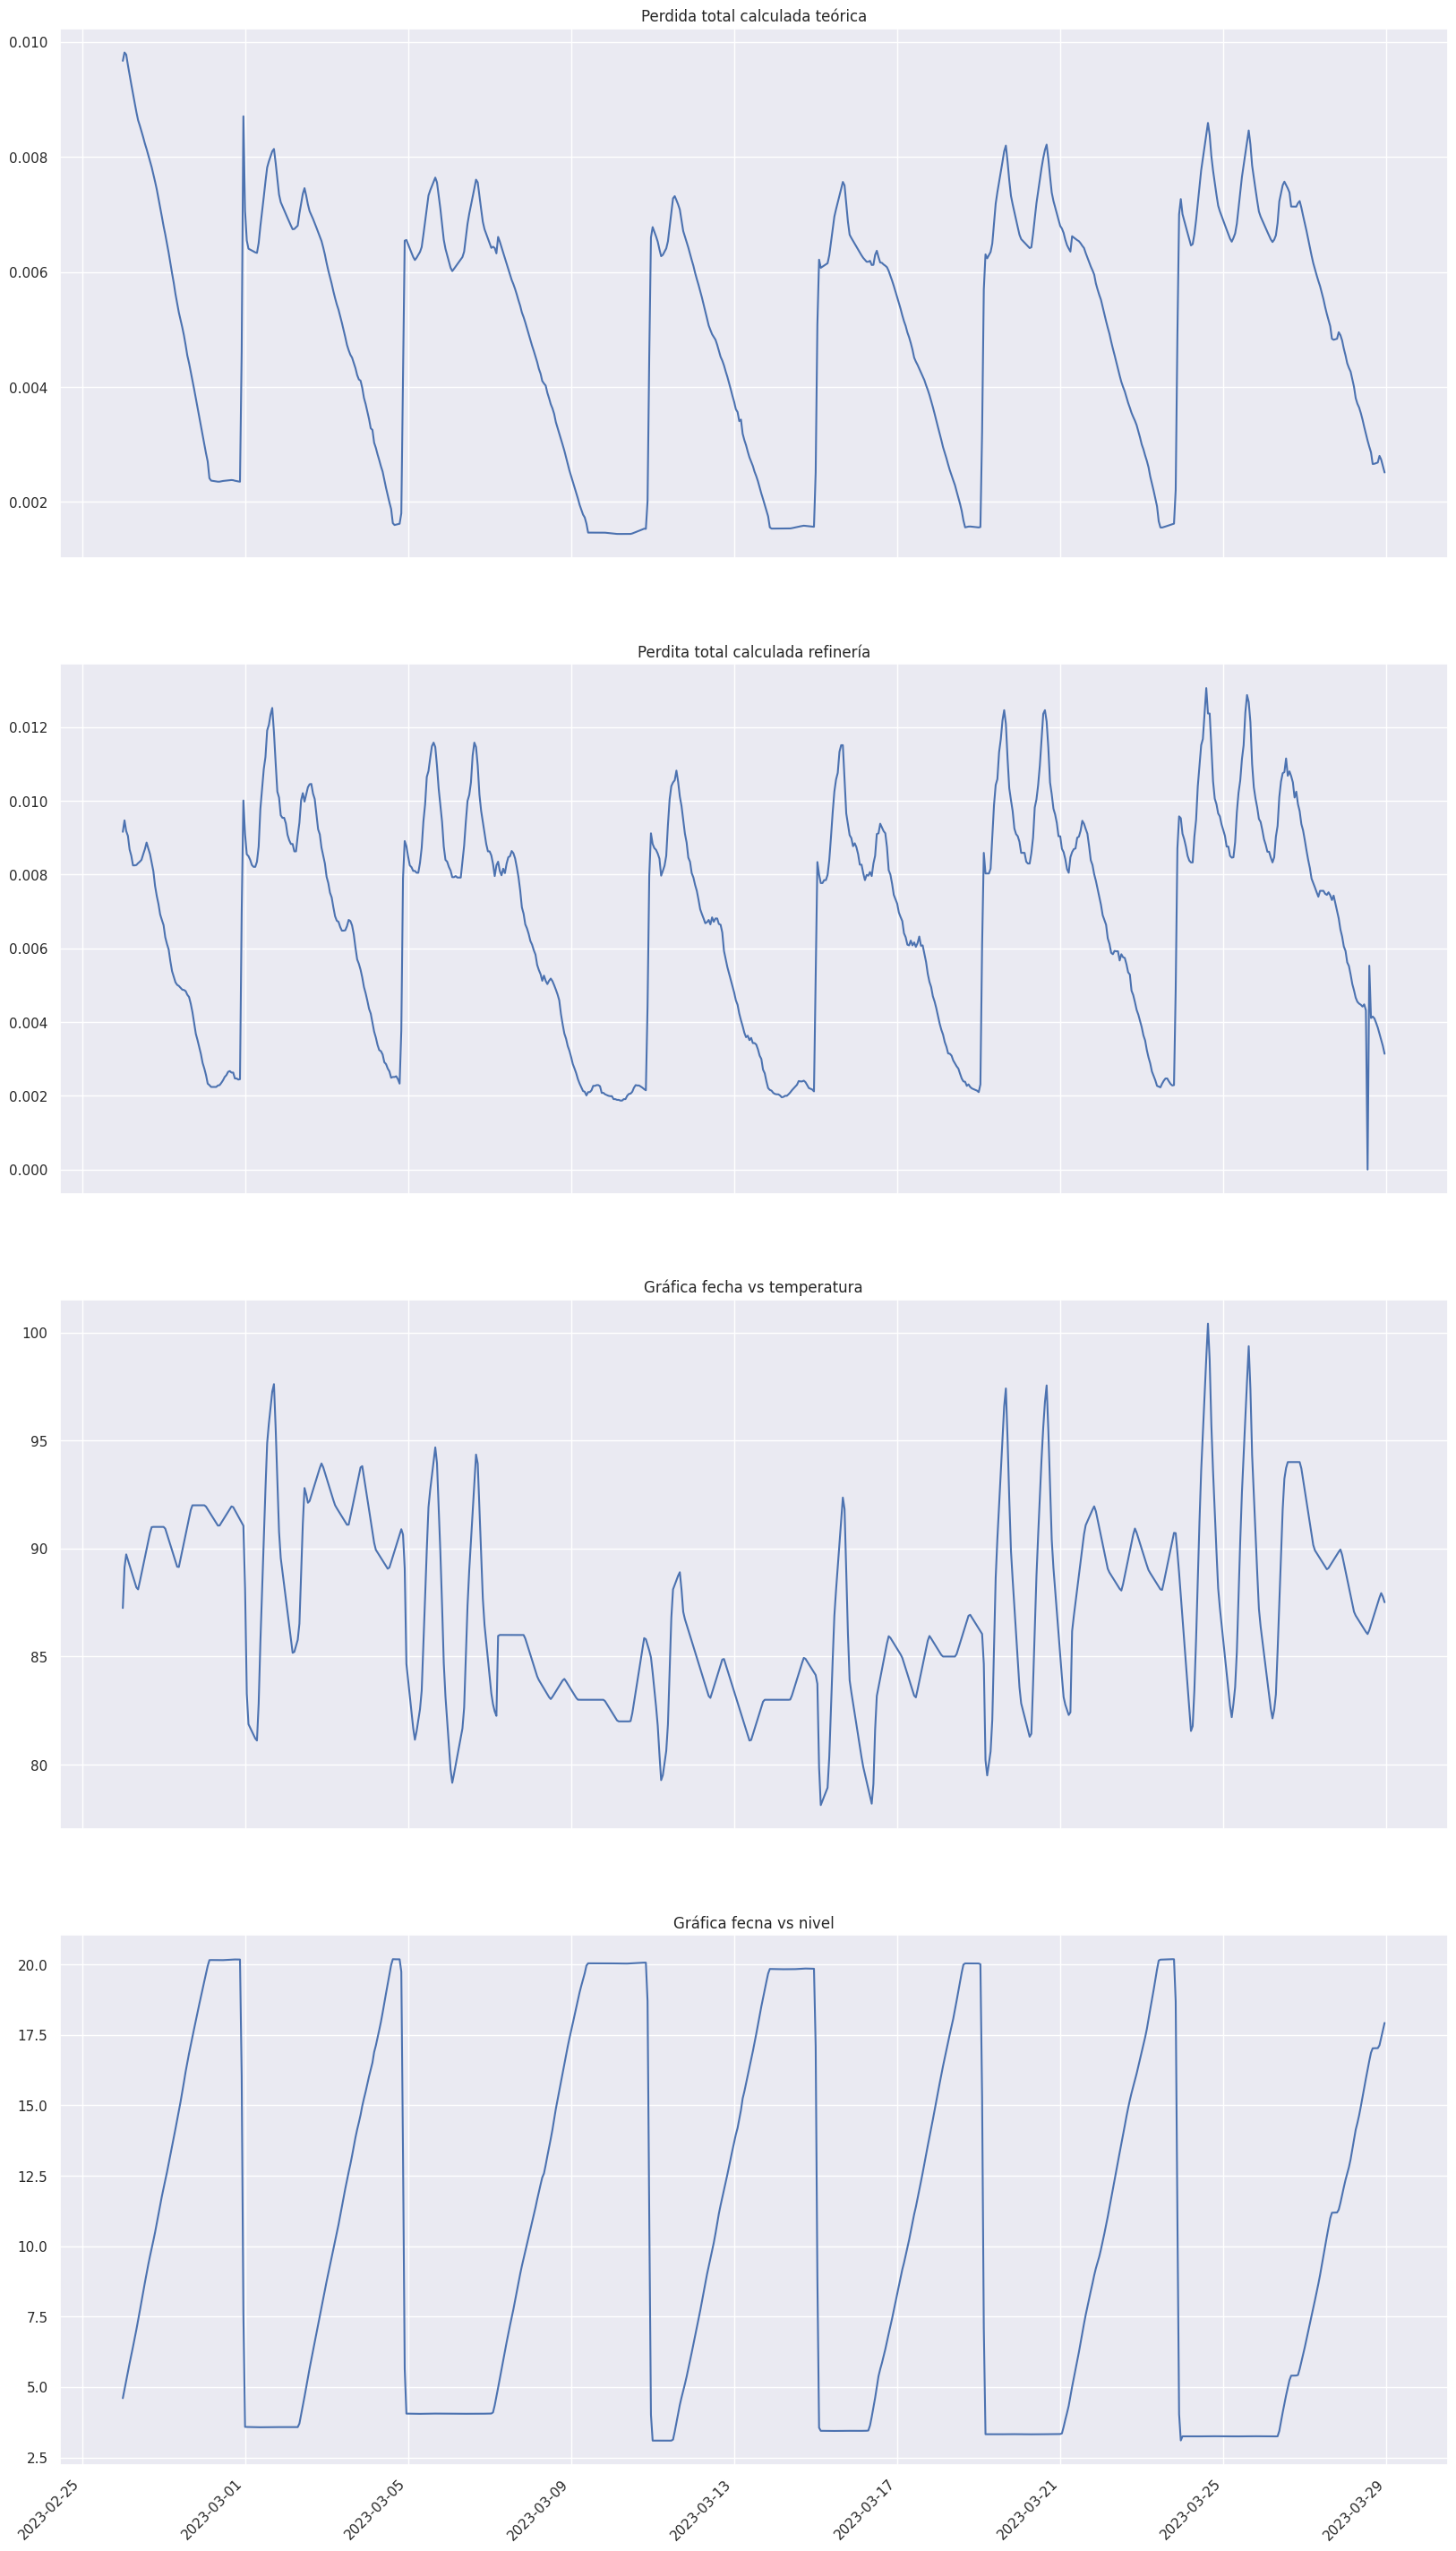

In [46]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(4, 1, figsize=(20, 40))

# Graficar los valores en el primer subplot
ax[0].plot(total['date'], total['lt'])
ax[0].set_title('Perdida total calculada teórica')

# Graficar los valores en el segundo subplot
ax[1].plot(total['date'], total['lt_oil_gas'])
ax[1].set_title('Perdita total calculada refinería')

# Graficar los valores en el segundo subplot
ax[2].plot(total['date'], total['tb'])
ax[2].set_title('Gráfica fecha vs temperatura')

# Graficar los valores en el segundo subplot
ax[3].plot(total['date'], total['hl'])
ax[3].set_title('Gráfica fecna vs nivel')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

# COMPARACIÓN TIEMPO VS PERDIDA TOTAL

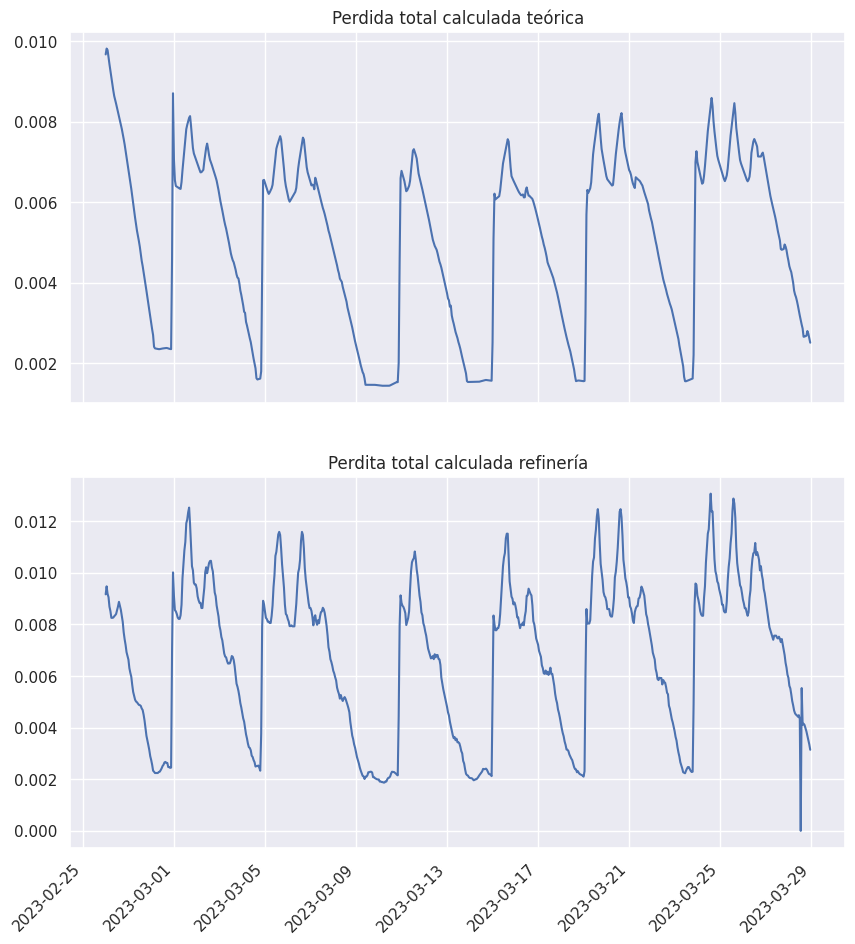

In [47]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# Graficar los valores en el primer subplot
ax[0].plot(total['date'], total['lt'])
ax[0].set_title('Perdida total calculada teórica')

# Graficar los valores en el segundo subplot
ax[1].plot(total['date'], total['lt_oil_gas'])
ax[1].set_title('Perdita total calculada refinería')


# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

# COMPARACIÓN TIEMPO VS PORCENTAJE DE ERROR

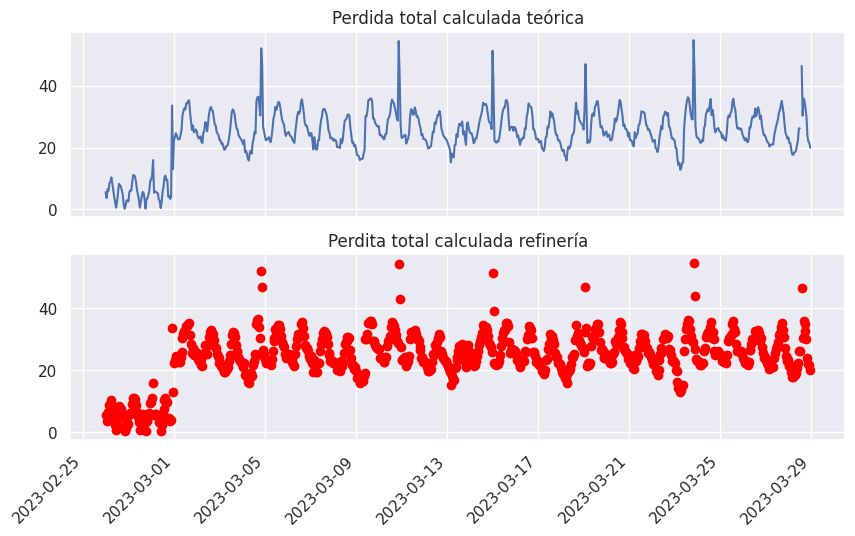

In [48]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'], total['error_percent'], label='porcentaje de error')
ax[0].set_title('Perdida total calculada teórica')

# Crear la gráfica de puntos
ax[1].scatter(total['date'], total['error_percent'], color='red', marker='o', label='')
ax[1].set_title('Perdita total calculada refinería')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

# TIEMPO VS TEMPERATURA

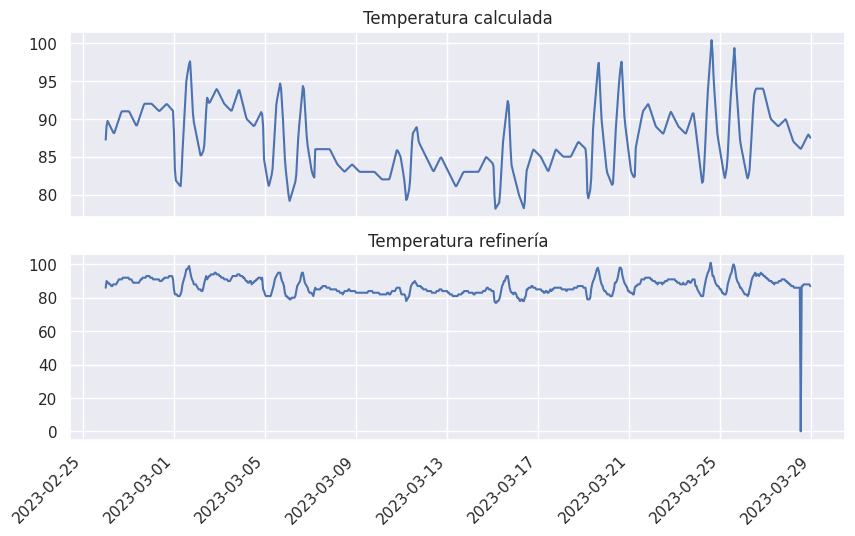

In [49]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'], total['tb'], label='temperatura')
ax[0].set_title('Temperatura calculada')

# Crear la gráfica de puntos
ax[1].plot(total['date'], total['tb_oil_gas'], label='temperatura')
ax[1].set_title('Temperatura refinería')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

# TIEMPO VS NIVEL

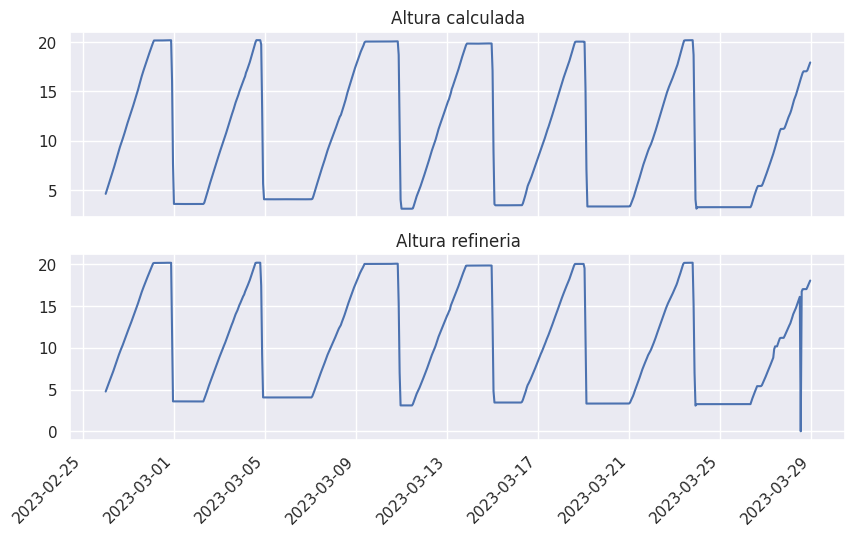

In [50]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'], total['hl'], label='temperatura')
ax[0].set_title('Altura calculada')

# Crear la gráfica de puntos
ax[1].plot(total['date'], total['hl_oil_gas'], label='temperatura')
ax[1].set_title('Altura refineria')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

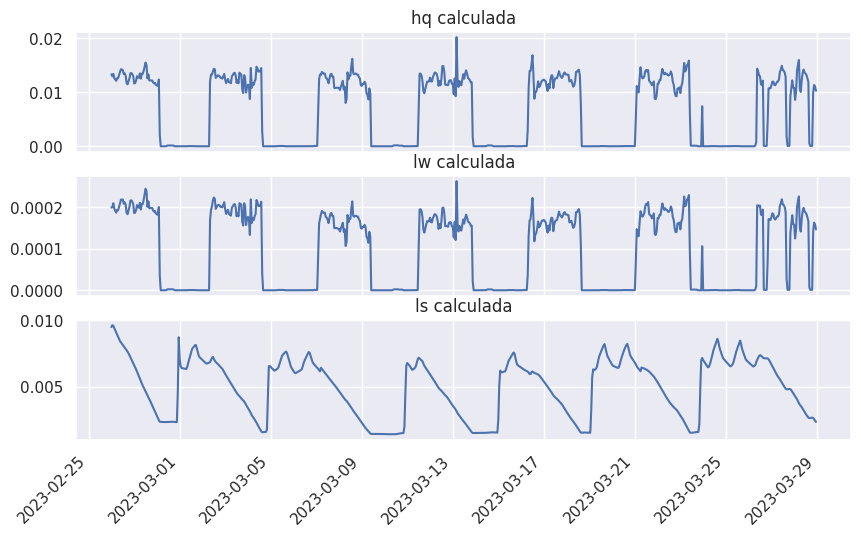

In [51]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(3, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'], total['hq'], label='temperatura')
ax[0].set_title('hq calculada')

ax[1].plot(total['date'], total['lw'], label='temperatura')
ax[1].set_title('lw calculada')

ax[2].plot(total['date'], total['ls'], label='temperatura')
ax[2].set_title('ls calculada')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

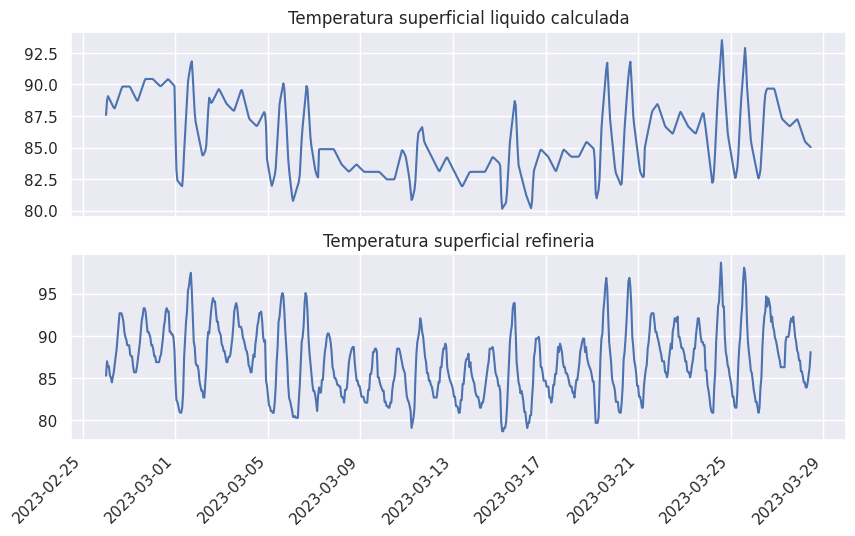

In [52]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'].values[:-12], total['tla'].values[:-12]-459.67, label='temperatura')
ax[0].set_title('Temperatura superficial liquido calculada')

# Crear la gráfica de puntos
ax[1].plot(total['date'].values[:-12], np.float64(total['tla_oil_gas'].values[:-12]), label='temperatura')
ax[1].set_title('Temperatura superficial refineria')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

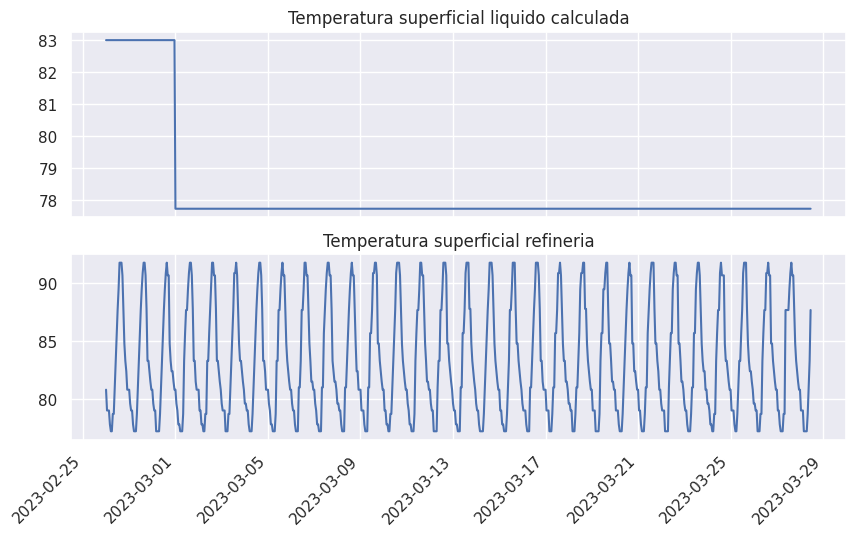

In [53]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'].values[:-12], total['taa'].values[:-12]-459.67, label='temperatura')
ax[0].set_title('Temperatura superficial liquido calculada')

# Crear la gráfica de puntos
ax[1].plot(total['date'].values[:-12], np.float64(total['taa_oil_gas'].values[:-12]), label='temperatura')
ax[1].set_title('Temperatura superficial refineria')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

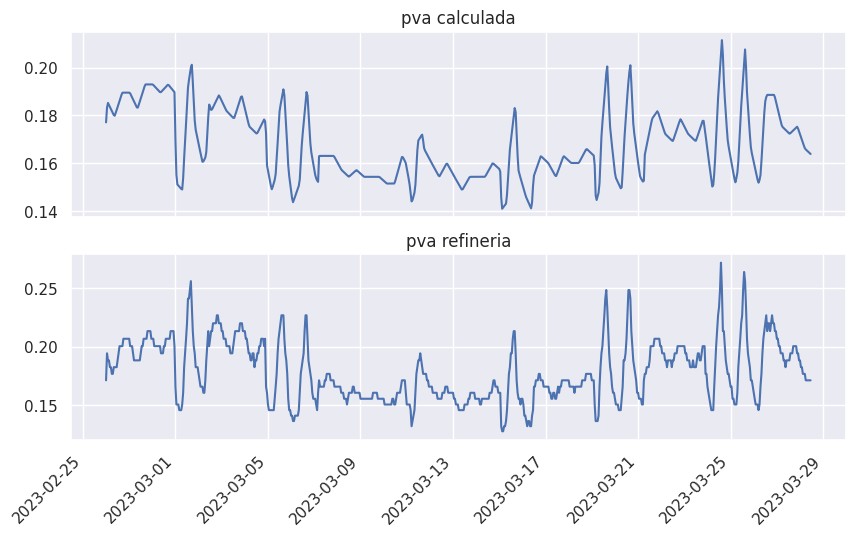

In [54]:
# Crear una figura con dos subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Crear la gráfica lineal
ax[0].plot(total['date'].values[:-12], total['pva'].values[:-12], label='temperatura')
ax[0].set_title('pva calculada')

# Crear la gráfica de puntos
ax[1].plot(total['date'].values[:-12], np.float64(total['pva_oil_gas'].values[:-12]), label='temperatura')
ax[1].set_title('pva refineria')

# Ajustar las etiquetas de fechas inclinadas en el eje x
fig.autofmt_xdate(rotation=45)

# Mostrar la figura
plt.show()

In [55]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(total["lt"], total["lt_oil_gas"])
mse2 = mean_squared_error(total["taa"], total["taa_oil_gas"])
porcentaje_error = (np.abs( np.float64(total["taa"][:-12]-459.67) - np.float64(total["taa_oil_gas"][:-12])) / np.float64(total["taa_oil_gas"][:-12]))*100
porcentaje_error_lt = (np.abs( np.float64(total["lt"][:-12]) - np.float64(total["lt_oil_gas"][:-12])) / np.float64(total["lt_oil_gas"][:-12]))*100
porcentaje_error_tla = (np.abs( np.float64(total["tla"][:-12]-459.67) - np.float64(total["tla_oil_gas"][:-12])) / np.float64(total["tla_oil_gas"][:-12]))*100
porcentaje_error_pva = (np.abs( np.float64(total["pva"][:-12]) - np.float64(total["pva_oil_gas"][:-12])) / np.float64(total["pva_oil_gas"][:-12]))*100

print(np.mean(porcentaje_error))
print(np.mean(porcentaje_error_lt))
print(np.mean(porcentaje_error_tla))
print(np.mean(porcentaje_error_pva))
print(mse)

6.351932321027755
24.315724837448702
2.2303350159210202
6.41966614871849
4.001166047731794e-06
